### Alejandro Quesada y Pablo Marin - 07-03-26
### Mineria de Datos 2
### EDA para los datos de turismo

In [1]:
import warnings
import pandas as pd
import numpy  as np
import seaborn as sns
import matplotlib.pyplot as plt
# Suppress all warnings
warnings.filterwarnings("ignore")

In [2]:
from src.utils import path


In [3]:
directorio_proyecto = path.obtener_ruta_local()
df = pd.read_csv(directorio_proyecto+'\\data\\raw\\tourism.csv',delimiter = ',',decimal = ".", encoding='utf-8')

In [4]:
# primeras filas
print("PRIMERAS FILAS DEL DATASET")
display(df.head(5))

print("ÚLTIMAS FILAS DEL DATASET")
display(df.tail(5))

PRIMERAS FILAS DEL DATASET


,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
0,1,48,"['Architecture', 'Art', 'History']",5,False,Eiffel Tower,"['Eiffel Tower', 'Great Wall of China', 'Taj M...",7,1000,1.6,3.73,97,4.5,3
1,2,37,"['Cultural', 'Nature']",6,False,Colosseum,['Great Wall of China'],1,2000,2.6,2.89,90,4.5,3
2,3,43,"['History', 'Art', 'Architecture']",6,True,Machu Picchu,['Eiffel Tower'],2,3000,1.7,2.22,94,4.7,3
3,4,46,"['Cultural', 'Art', 'Architecture']",8,False,Colosseum,"['Machu Picchu', 'Taj Mahal']",5,4000,2.0,2.34,92,4.7,3
4,5,53,"['Architecture', 'Art']",5,True,Colosseum,"['Machu Picchu', 'Taj Mahal', 'Great Wall of C...",7,5000,3.7,2.00,96,4.8,4


ÚLTIMAS FILAS DEL DATASET


,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
4995,4996,31,"['Architecture', 'History', 'Cultural']",3,False,Great Wall of China,['Great Wall of China'],2,4996000,3.9,2.53,100,4.4,4
4996,4997,28,"['Architecture', 'Cultural', 'Nature']",7,True,Great Wall of China,['Colosseum'],1,4997000,4.3,1.53,100,5.0,4
4997,4998,42,"['History', 'Cultural', 'Nature']",3,True,Machu Picchu,['Taj Mahal'],1,4998000,3.2,3.99,89,4.4,3
4998,4999,58,"['Cultural', 'Art', 'History']",5,False,Colosseum,"['Taj Mahal', 'Great Wall of China', 'Colosseum']",7,4999000,2.5,2.13,98,4.4,3
4999,5000,32,['Nature'],4,False,Colosseum,['Great Wall of China'],1,5000000,1.9,2.99,92,4.8,3


In [5]:
# Dimensiones del dataset
print("DIMENSIONES DEL DATASET")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

# Información general
print("INFORMACIÓN GENERAL")
df.info()

DIMENSIONES DEL DATASET
Número de filas: 5000
Número de columnas: 14
INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tourist ID               5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Interests                5000 non-null   object 
 3   Preferred Tour Duration  5000 non-null   int64  
 4   Accessibility            5000 non-null   bool   
 5   Site Name                5000 non-null   object 
 6   Sites Visited            5000 non-null   object 
 7   Tour Duration            5000 non-null   int64  
 8   Route ID                 5000 non-null   int64  
 9   Tourist Rating           5000 non-null   float64
 10  System Response Time     5000 non-null   float64
 11  Recommendation Accuracy  5000 non-null   int64  
 12  VR Experience Quality    5000 non-null   fl

In [6]:
# Tipos de datos
print("TIPOS DE DATOS")
print(df.dtypes)

TIPOS DE DATOS
Tourist ID                   int64
Age                          int64
Interests                   object
Preferred Tour Duration      int64
Accessibility                 bool
Site Name                   object
Sites Visited               object
Tour Duration                int64
Route ID                     int64
Tourist Rating             float64
System Response Time       float64
Recommendation Accuracy      int64
VR Experience Quality      float64
Satisfaction                 int64
dtype: object


In [7]:
# Estadísticas descriptivas de variables numéricas
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
display(df.describe().T)

# Estadísticas adicionales
print("ESTADÍSTICAS ADICIONALES")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Media: {df[col].mean():.2f}")
    print(f"  Mediana: {df[col].median():.2f}")
    print(f"  Moda: {df[col].mode().values[0] if len(df[col].mode()) > 0 else 'N/A'}")
    print(f"  Desviación estándar: {df[col].std():.2f}")
    print(f"  Varianza: {df[col].var():.2f}")
    print(f"  Asimetría (Skewness): {df[col].skew():.2f}")
    print(f"  Curtosis (Kurtosis): {df[col].kurtosis():.2f}")

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
Tourist ID,5000.0,2.500500e+03,1.443520e+03,1.0,1250.75,2500.50,3750.25,5000.0
Age,5000.0,4.388600e+01,1.526886e+01,18.0,30.00,44.00,57.00,70.0
Preferred Tour Duration,5000.0,5.522800e+00,1.711860e+00,3.0,4.00,6.00,7.00,8.0
Tour Duration,5000.0,3.977200e+00,1.999670e+00,1.0,2.00,4.00,5.00,9.0
Route ID,5000.0,2.500500e+06,1.443520e+06,1000.0,1250750.00,2500500.00,3750250.00,5000000.0
Tourist Rating,5000.0,3.002740e+00,1.164353e+00,1.0,2.00,3.00,4.00,5.0
System Response Time,5000.0,3.238802e+00,1.016123e+00,1.5,2.36,3.23,4.13,5.0
Recommendation Accuracy,5000.0,9.249220e+01,4.616081e+00,85.0,88.00,92.00,97.00,100.0
VR Experience Quality,5000.0,4.493160e+00,2.905961e-01,4.0,4.20,4.50,4.70,5.0
Satisfaction,5000.0,3.534200e+00,7.360290e-01,3.0,3.00,3.00,4.00,5.0


ESTADÍSTICAS ADICIONALES

Tourist ID:
  Media: 2500.50
  Mediana: 2500.50
  Moda: 1
  Desviación estándar: 1443.52
  Varianza: 2083750.00
  Asimetría (Skewness): 0.00
  Curtosis (Kurtosis): -1.20

Age:
  Media: 43.89
  Mediana: 44.00
  Moda: 25
  Desviación estándar: 15.27
  Varianza: 233.14
  Asimetría (Skewness): 0.01
  Curtosis (Kurtosis): -1.21

Preferred Tour Duration:
  Media: 5.52
  Mediana: 6.00
  Moda: 6
  Desviación estándar: 1.71
  Varianza: 2.93
  Asimetría (Skewness): -0.03
  Curtosis (Kurtosis): -1.27

Tour Duration:
  Media: 3.98
  Mediana: 4.00
  Moda: 3
  Desviación estándar: 2.00
  Varianza: 4.00
  Asimetría (Skewness): 0.35
  Curtosis (Kurtosis): -0.67

Route ID:
  Media: 2500500.00
  Mediana: 2500500.00
  Moda: 1000
  Desviación estándar: 1443520.00
  Varianza: 2083750000000.00
  Asimetría (Skewness): 0.00
  Curtosis (Kurtosis): -1.20

Tourist Rating:
  Media: 3.00
  Mediana: 3.00
  Moda: 4.5
  Desviación estándar: 1.16
  Varianza: 1.36
  Asimetría (Skewness): 0.00


In [8]:
# Estadísticas de variables categóricas
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Valores únicos: {df[col].nunique()}")
    print(f"  Valor más frecuente: {df[col].mode().values[0] if len(df[col].mode()) > 0 else 'N/A'}")
    print(f"  Top 5 valores:")
    print(df[col].value_counts().head())

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS

Interests:
  Valores únicos: 85
  Valor más frecuente: ['Art']
  Top 5 valores:
Interests
['Art']             353
['Cultural']        352
['History']         340
['Nature']          338
['Architecture']    323
Name: count, dtype: int64

Site Name:
  Valores únicos: 5
  Valor más frecuente: Great Wall of China
  Top 5 valores:
Site Name
Great Wall of China    1013
Eiffel Tower           1011
Taj Mahal              1003
Colosseum               988
Machu Picchu            985
Name: count, dtype: int64

Sites Visited:
  Valores únicos: 85
  Valor más frecuente: ['Eiffel Tower']
  Top 5 valores:
Sites Visited
['Eiffel Tower']           348
['Taj Mahal']              336
['Great Wall of China']    335
['Colosseum']              335
['Machu Picchu']           299
Name: count, dtype: int64


In [9]:
# Análisis de duplicados
print("ANÁLISIS DE VALORES DUPLICADOS")
print(f"Número de filas duplicadas: {df.duplicated().sum()}")
print(f"Porcentaje de duplicados: {(df.duplicated().sum() / len(df)) * 100:.2f}%")

if df.duplicated().sum() > 0:
    print("\nFilas duplicadas:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))

ANÁLISIS DE VALORES DUPLICADOS
Número de filas duplicadas: 0
Porcentaje de duplicados: 0.00%


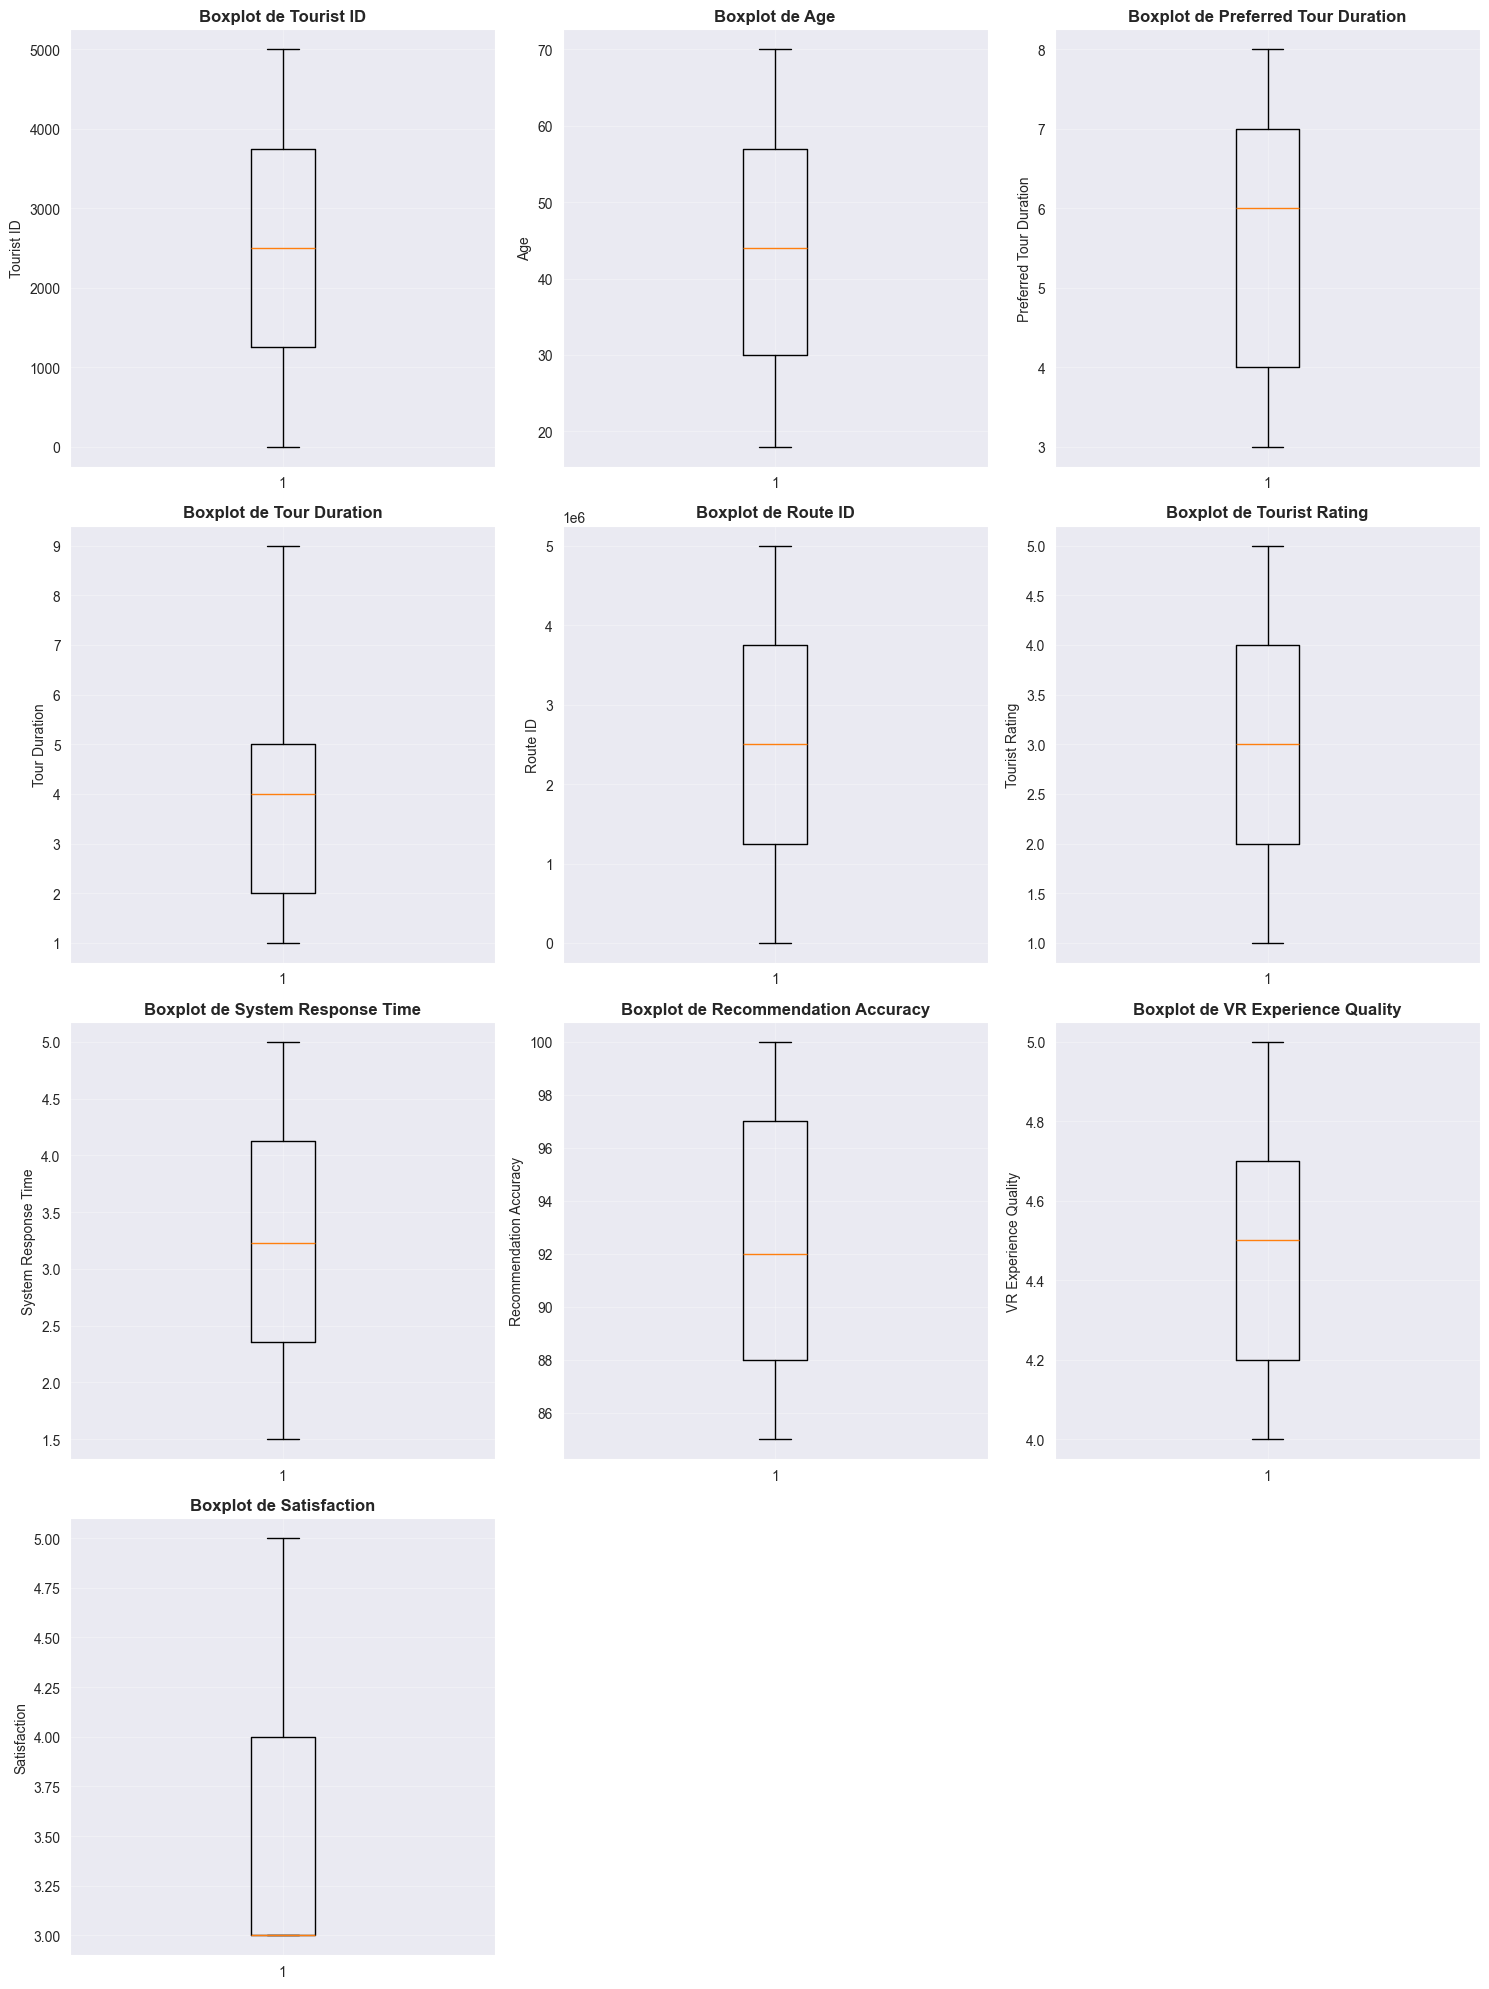

In [10]:
# Boxplots para detectar outliers
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 0:
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]

    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Boxplot de {col}', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3)

    # Ocultar ejes vacíos
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

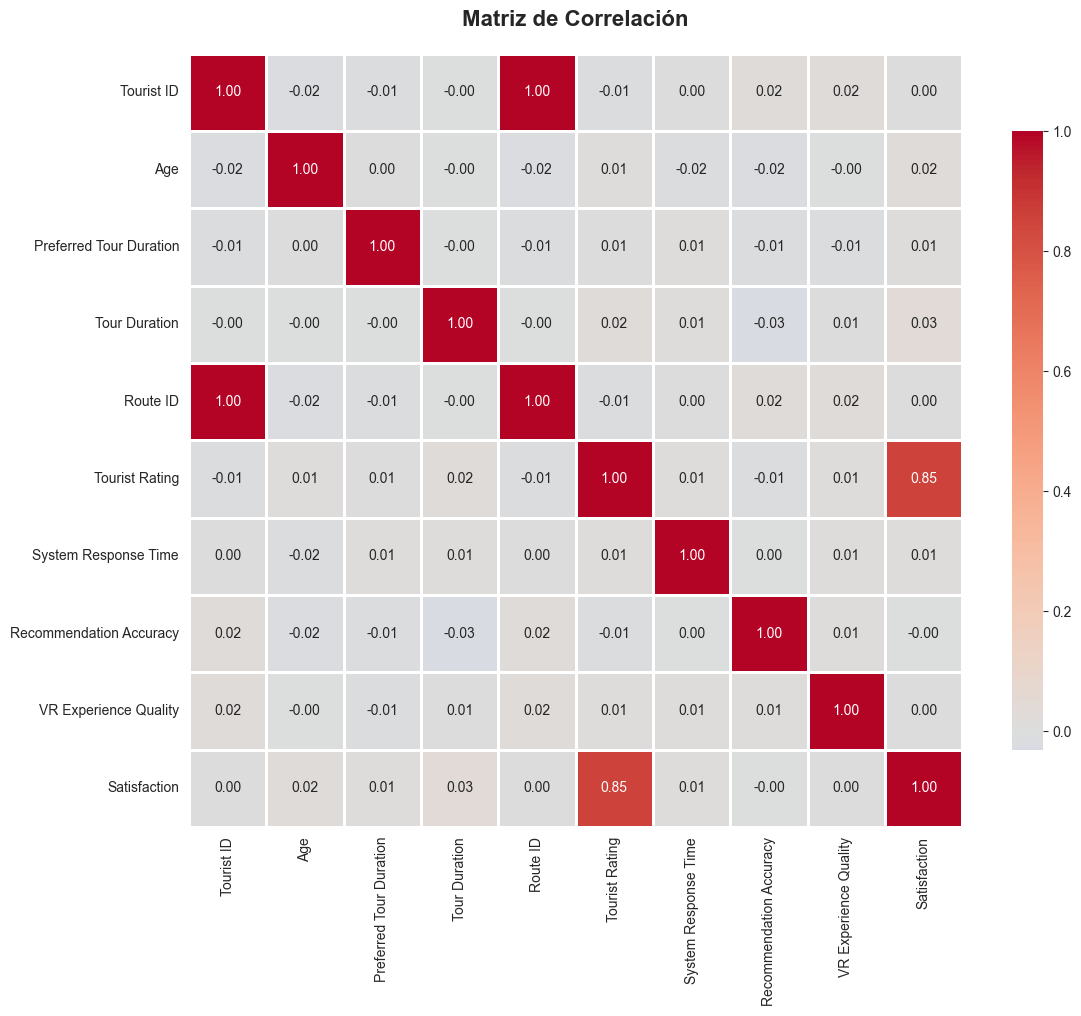

In [11]:
import seaborn as sns

# Matriz de correlación
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

In [12]:
# Age: Grupos etarios
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Preferred Tour Duration: Duración preferida
df['Tour_Duration_Pref'] = pd.cut(df['Preferred Tour Duration'],
                                   bins=[0, 4, 7, 10, 100],
                                   labels=['Corta(1-4h)', 'Media(5-7h)', 'Larga(8-10h)', 'Muy_Larga(>10h)'])

# Tourist Rating: Categorías de rating
df['Rating_Category'] = pd.cut(df['Tourist Rating'],
                                bins=[0, 2.0, 3.5, 5.0],
                                labels=['Bajo', 'Medio', 'Alto'])

# System Response Time: Velocidad del sistema
df['Response_Speed'] = pd.cut(df['System Response Time'],
                               bins=[0, 2.5, 3.5, 100],
                               labels=['Rápido', 'Normal', 'Lento'])

# Recommendation Accuracy: Precisión
df['Accuracy_Level'] = pd.cut(df['Recommendation Accuracy'],
                               bins=[0, 85, 95, 100],
                               labels=['Baja', 'Media', 'Alta'])

# VR Experience Quality: Calidad VR
df['VR_Quality'] = pd.cut(df['VR Experience Quality'],
                          bins=[0, 4.0, 4.5, 5.0],
                          labels=['Regular', 'Buena', 'Excelente'])

# Satisfaction: Ya parece discreta pero podemos asegurar
df['Satisfaction_Level'] = df['Satisfaction'].apply(lambda x:
    'Baja' if x <= 2 else 'Media' if x == 3 else 'Alta')


In [13]:
import ast

# Identificar columnas que tienen formato de lista
list_columns = ['Sites Visited', 'Interests']  # Ajusta según tus columnas

for col in list_columns:
    df[col] = df[col].apply(
        lambda x: ', '.join(ast.literal_eval(x)) if isinstance(x, str) else ', '.join(x)
    )


In [14]:
df

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,...,Recommendation Accuracy,VR Experience Quality,Satisfaction,Age_Group,Tour_Duration_Pref,Rating_Category,Response_Speed,Accuracy_Level,VR_Quality,Satisfaction_Level
0,1,48,"Architecture, Art, History",5,False,Eiffel Tower,"Eiffel Tower, Great Wall of China, Taj Mahal",7,1000,1.6,...,97,4.5,3,46-55,Media(5-7h),Bajo,Lento,Alta,Buena,Media
1,2,37,"Cultural, Nature",6,False,Colosseum,Great Wall of China,1,2000,2.6,...,90,4.5,3,36-45,Media(5-7h),Medio,Normal,Media,Buena,Media
2,3,43,"History, Art, Architecture",6,True,Machu Picchu,Eiffel Tower,2,3000,1.7,...,94,4.7,3,36-45,Media(5-7h),Bajo,Rápido,Media,Excelente,Media
3,4,46,"Cultural, Art, Architecture",8,False,Colosseum,"Machu Picchu, Taj Mahal",5,4000,2.0,...,92,4.7,3,46-55,Larga(8-10h),Bajo,Rápido,Media,Excelente,Media
4,5,53,"Architecture, Art",5,True,Colosseum,"Machu Picchu, Taj Mahal, Great Wall of China",7,5000,3.7,...,96,4.8,4,46-55,Media(5-7h),Alto,Rápido,Alta,Excelente,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,31,"Architecture, History, Cultural",3,False,Great Wall of China,Great Wall of China,2,4996000,3.9,...,100,4.4,4,26-35,Corta(1-4h),Alto,Normal,Alta,Buena,Alta
4996,4997,28,"Architecture, Cultural, Nature",7,True,Great Wall of China,Colosseum,1,4997000,4.3,...,100,5.0,4,26-35,Media(5-7h),Alto,Rápido,Alta,Excelente,Alta
4997,4998,42,"History, Cultural, Nature",3,True,Machu Picchu,Taj Mahal,1,4998000,3.2,...,89,4.4,3,36-45,Corta(1-4h),Medio,Lento,Media,Buena,Media
4998,4999,58,"Cultural, Art, History",5,False,Colosseum,"Taj Mahal, Great Wall of China, Colosseum",7,4999000,2.5,...,98,4.4,3,56+,Media(5-7h),Medio,Rápido,Alta,Buena,Media


In [15]:
df.to_csv(directorio_proyecto+'\\data\\procesed\\datos_tourism.csv', index=False)